# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name: Eliza Liva Kalnina
## Date: 03/08/2026
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [30]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [31]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [32]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [33]:

X_encoded = pd.get_dummies(X)
X_encoded.head()


,odor_a,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,spore-print-color_b,...,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,bruises_f,bruises_t
0,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 5️⃣ Train/test split (Add Code)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42
)

print(X_train.shape, X_test.shape)


(6093, 34) (2031, 34)


## 6️⃣ Train a small decision tree (Add Code)

In [35]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=5, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [36]:

y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9940915805022157
Confusion Matrix:
[[1040    0]
 [  12  979]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1040
           1       1.00      0.99      0.99       991

    accuracy                           0.99      2031
   macro avg       0.99      0.99      0.99      2031
weighted avg       0.99      0.99      0.99      2031



## 8️⃣ Visualize the decision tree (Add Code)

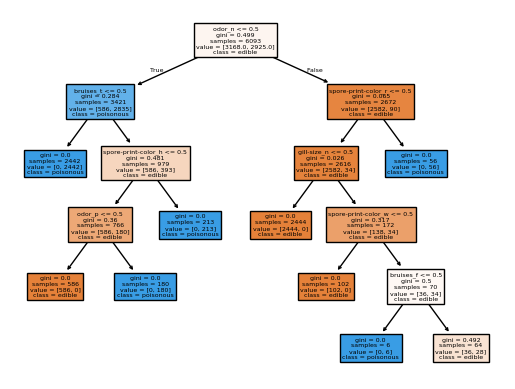

In [37]:
plt.figure()
plot_tree(
    tree,
    feature_names=X_encoded.columns,
    class_names=["edible", "poisonous"],
    filled=True
)
plt.show()


## 9️⃣ Print IF–THEN rules (Add Code)

In [38]:

print(export_text(tree, feature_names=list(X_encoded.columns)))

|--- odor_n <= 0.50
|   |--- bruises_t <= 0.50
|   |   |--- class: 1
|   |--- bruises_t >  0.50
|   |   |--- spore-print-color_h <= 0.50
|   |   |   |--- odor_p <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- odor_p >  0.50
|   |   |   |   |--- class: 1
|   |   |--- spore-print-color_h >  0.50
|   |   |   |--- class: 1
|--- odor_n >  0.50
|   |--- spore-print-color_r <= 0.50
|   |   |--- gill-size_n <= 0.50
|   |   |   |--- class: 0
|   |   |--- gill-size_n >  0.50
|   |   |   |--- spore-print-color_w <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- spore-print-color_w >  0.50
|   |   |   |   |--- bruises_f <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- bruises_f >  0.50
|   |   |   |   |   |--- class: 0
|   |--- spore-print-color_r >  0.50
|   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy? <br> 0.9556868537666174
2. How many poisonous mushrooms were correctly classified? 901
3. How many poisonous mushrooms were incorrectly predicted as edible? 90
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one? If someone eats poisonous mushroom, they can actually die. While if a mushroom is  classified as poisonous and actually is not, the only consequence that no one would eat the mushroom.

### Understanding the Tree
5. What feature appears at the **root node**? smell of the mushroom
6. What question is the root node asking in plain English? It is asking for the type of smell
7. Describe what the **left branch** and **right branch** mean.
The left branch means that the mushroom does not have a specific smell, while the right branch means that the mushroom has an odor and could be poisonous
### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on? gill color, gill size, bruises, or spore print color.
   - What question is each node asking? if that mushroom has that specific feature
   - What does following the left vs right branch mean? following left branch means that the condition is false, while the right branch means that the condition is true

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English. If the mushroom does not have odor type "n" and does not have bruises, the model predicts that the mushroom is poisonous.
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous? The most important feature is odor, because it appears at the root node of the tree. This means the model uses the mushroom’s smell first to separate edible and poisonous mushrooms before looking at any other features.

### Exploration
11. Change `max_depth` to 2. What changed? The decision tree have fewer levels and fewer splits. It became simpler. The accuracy dropped from about 95.6% to about 91.9%. The number of poisonous mushrooms incorrectly predicted as edible increased from 90 to 165
12. Change `max_depth` to 5. What changed? The decision tree became larger and more complex. The accuracy increased from about 91.9% to about 99.4%. The number of poisonous mushrooms incorrectly predicted as edible also decreased from 165 to only 12. This model is more complex, but also way more accurate.
